In [2]:
import tensorflow as tf

2026-03-10 12:09:28.229430: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
mnist = tf.keras.datasets.mnist

In [4]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
#normalizacja danych
x_train, x_test = x_train/255.0, x_test/255.0

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
#budowa sieci neuronowej
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'), #relu = max(0,x)
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

model.summary()

/opt/python/envs/default_3_11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type) ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten ( Flatten ) │ ( None , 784 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense ( Dense ) │ ( None , 128 ) │ 100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout ( Dropout ) │ ( None , 128 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 ( Dense ) │ ( None , 10 ) │ 1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 101,770 (397.54 KB)

Trainable params: 101,770 (397.54 KB)

Non-trainable params: 0 (0.00 B)

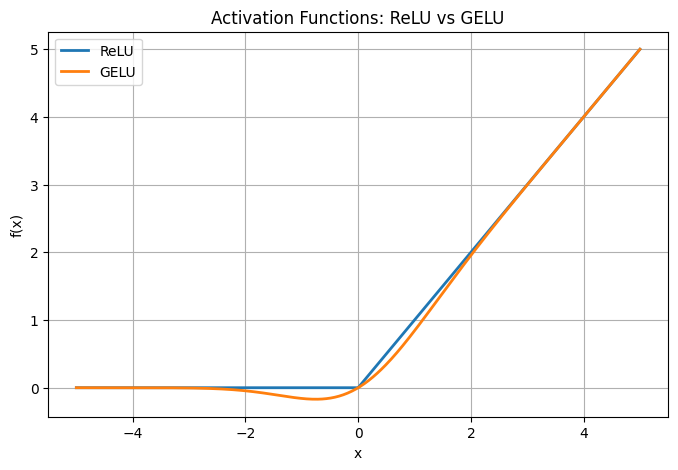

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# zakres x
x = np.linspace(-5, 5, 400)

# ReLU
def relu(x):
    return np.maximum(0, x)

# GELU (dokładna wersja)
def gelu(x):
    return x * norm.cdf(x)

# obliczenia
y_relu = relu(x)
y_gelu = gelu(x)

# rysowanie wykresów
plt.figure(figsize=(8,5))
plt.plot(x, y_relu, label="ReLU", linewidth=2)
plt.plot(x, y_gelu, label="GELU", linewidth=2)

plt.title("Activation Functions: ReLU vs GELU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()

plt.show()

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy']
)

In [11]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9146 - loss: 0.2934
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9583 - loss: 0.1436
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9661 - loss: 0.1097
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9731 - loss: 0.0867
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9762 - loss: 0.0765
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9794 - loss: 0.0641
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9808 - loss: 0.0583
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9830 - loss: 0.0523
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9837 - loss: 0.0485
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9852 - loss: 0.0444


2026-03-10 12:09:44.900304: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


In [13]:
#ocena modelu
test_loss,test_acc = model.evaluate(x_test,y_test)
print(f"strata: {test_loss}")
print(f"dokładnosć: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9802 - loss: 0.0722
strata: 0.07217562198638916
dokładnosć: 0.9801999926567078
